# 01 — Data pipeline

Fonti in ordine di qualità: **SEC EDGAR** (ufficiale) > **Polymarket Gamma** (soldi veri) > **FRED** (macro ufficiale) > **yfinance** (mercato, con fallback Stooq). Ogni fetch passa da un quality report. Universe: portafoglio (GOOGL), comparabili volatilità (TSLA), 'pale e picconi' (NDAQ, HOOD, VIRT, GS, MS), benchmark (^GSPC, ^NDX).

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.viz import tufte_style, direct_label_lines, corr_heatmap, pnl_distribution, PALETTE
tufte_style()

## 1. OHLCV con quality report

Regola data-engineering: nessun dato entra nel processo senza passare i check (NaN, gap, prezzi non positivi, salti >50%, staleness).

In [2]:
from src.connectors.market_data import get_universe
UNIVERSE = ["GOOGL", "TSLA", "NDAQ", "HOOD", "VIRT", "GS", "MS", "^GSPC", "^NDX"]
prices, reports = get_universe(UNIVERSE, period="2y")
qa = pd.DataFrame(reports).set_index("ticker")
assert qa["issues"].map(len).sum() == 0, f"QUALITY FAIL: {qa[qa.issues.map(len)>0]}"
prices.to_parquet("../data/universe_prices.parquet")
qa

,rows,first,last,missing_bdays,issues
ticker,,,,,
GOOGL,123,2025-12-10,2026-06-08,6,[]
TSLA,123,2025-12-10,2026-06-08,6,[]
NDAQ,500,2024-06-10,2026-06-08,21,[]
HOOD,500,2024-06-10,2026-06-08,21,[]
VIRT,500,2024-06-10,2026-06-08,21,[]
GS,500,2024-06-10,2026-06-08,21,[]
MS,500,2024-06-10,2026-06-08,21,[]
^GSPC,123,2025-12-10,2026-06-08,6,[]
^NDX,500,2024-06-10,2026-06-08,21,[]


## 2. SEC EDGAR — filing SpaceX (CIK 1181412)

La fonte più autorevole in assoluto: i filing sono atti legali. Da agosto qui compariranno i **Form 4** (vendite insider, pubblicate per legge entro 2 giorni lavorativi) — il dato chiave della strategia B.

In [3]:
from src.connectors.edgar import recent_filings, form4_watch
fil = pd.DataFrame(recent_filings(limit=15))
f4 = form4_watch()
print(f"Form 3/4/144 presenti: {len(f4)} (attesi da agosto)")
fil

Form 3/4/144 presenti: 0 (attesi da agosto)


,form,date,url
0,FWP,2026-06-09,https://www.sec.gov/Archives/edgar/data/118141...
1,FWP,2026-06-08,https://www.sec.gov/Archives/edgar/data/118141...
2,FWP,2026-06-05,https://www.sec.gov/Archives/edgar/data/118141...
3,FWP,2026-06-05,https://www.sec.gov/Archives/edgar/data/118141...
4,FWP,2026-06-04,https://www.sec.gov/Archives/edgar/data/118141...
5,FWP,2026-06-04,https://www.sec.gov/Archives/edgar/data/118141...
6,S-1/A,2026-06-03,https://www.sec.gov/Archives/edgar/data/118141...
7,S-1/A,2026-06-01,https://www.sec.gov/Archives/edgar/data/118141...
8,S-1,2026-05-20,https://www.sec.gov/Archives/edgar/data/118141...
9,DRS/A,2026-05-07,https://www.sec.gov/Archives/edgar/data/118141...


## 3. Polymarket — probabilità implicite con soldi veri

In [4]:
from src.connectors.polymarket import search_markets
mkts = search_markets("spacex", limit=10)
pm = pd.DataFrame([{ "market": m["market"], **{f"P({k})": v for k, v in m["outcomes"].items()}, "volume_usd": m["volume"]} for m in mkts])
pm

,market,P(Yes),P(No),volume_usd
0,SpaceX IPO closing market cap above $3T?,0.0450,0.9550,1.788893e+06
1,SpaceX IPO closing market cap above $2T?,0.6050,0.3950,1.065221e+06
2,Will SpaceX's market cap be between $2.5T and ...,0.1370,0.8630,9.071243e+05
3,"Will SpaceX IPO by May 31, 2026?",0.0000,1.0000,9.063127e+05
4,SpaceX IPO closing market cap above $1.8T?,0.7950,0.2050,9.014105e+05
5,SpaceX IPO closing market cap above $2.4T?,0.2150,0.7850,8.357514e+05
6,Will SpaceX's market cap be greater than $1T a...,0.9930,0.0070,7.392136e+05
7,SpaceX IPO closing market cap above $1T?,0.9935,0.0065,6.736481e+05
8,"Will SpaceX not IPO by December 31, 2027?",0.0020,0.9980,6.645941e+05
9,"Will SpaceX IPO by June 30, 2026?",0.9945,0.0055,6.581682e+05


## 4. Tasso risk-free (FRED, fallback ^IRX)

In [5]:
from src.connectors.fred import risk_free_rate
RF = risk_free_rate()
print(f"T-bill 3M: {RF:.2%} — da usare come hurdle: ogni strategia deve battere questo + attrito")

T-bill 3M: 3.63% — da usare come hurdle: ogni strategia deve battere questo + attrito


## 5. Prezzi normalizzati — un grafico, tutta l'informazione

Base 100, etichette dirette (niente legenda da decodificare), benchmark in grigio.

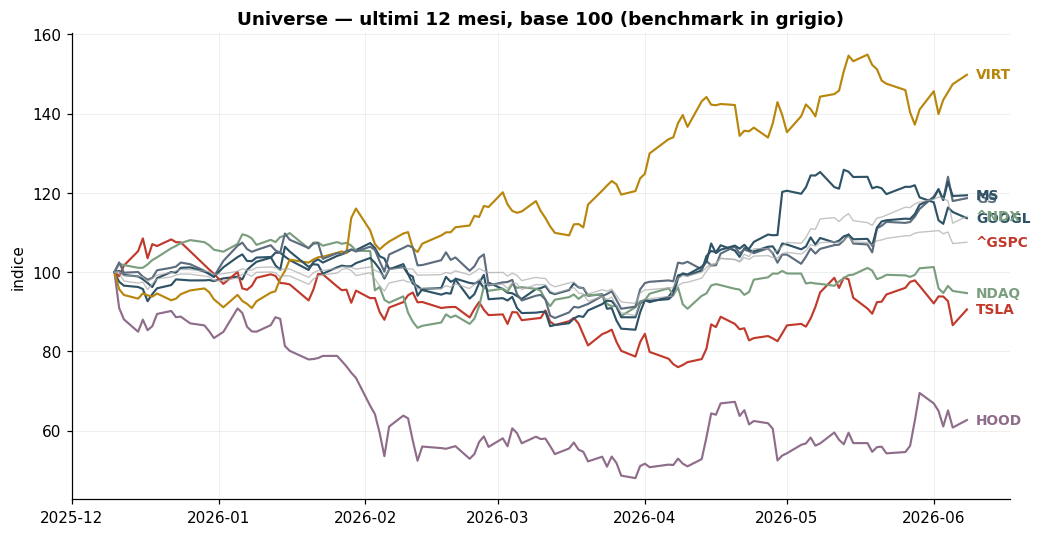

In [6]:
px = prices.dropna().tail(252)
norm = 100 * px / px.iloc[0]
fig, ax = plt.subplots(figsize=(11, 5.5))
for c in norm.columns:
    is_bench = c.startswith("^")
    ax.plot(norm.index, norm[c], lw=0.9 if is_bench else 1.4,
            color="#AAAAAA" if is_bench else None, alpha=0.7 if is_bench else 1)
direct_label_lines(ax, norm)
ax.set_title("Universe — ultimi 12 mesi, base 100 (benchmark in grigio)")
ax.set_ylabel("indice")
fig.savefig("../data/chart_universe.png", bbox_inches="tight")
plt.show()